# DDPM — From Gaussian Noise to 2D Geometric Patterns

### A visual laboratory for conditional diffusion on synthetic point clouds

Notebook 07 established the mathematical machinery of DDPMs: forward diffusion, the noise-prediction objective, and the reverse Gaussian process.

This notebook moves that machinery into a visual 2D laboratory.

The central question is:

> **Can a diffusion model learn difficult geometric point distributions and generate those distributions starting from pure Gaussian noise?**

We work with points

$$
x_0 =
\begin{bmatrix}
x\\
y
\end{bmatrix}
\in \mathbb{R}^2,
$$

and the forward diffusion equation from Notebook 07:

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 +
\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I_2).
$$

The conditional network predicts

$$
\epsilon_\theta(x_t,t,y),
$$

where $y$ is the geometric pattern class.

The notebook revolves around one visual idea:

```text
Gaussian Noise
      |
      v
  Reverse Diffusion
      |
      v
  Rough Structure
      |
      v
Recognizable Geometry
      |
      v
 Clean 2D Pattern
```

The final experiment makes this trajectory visible with animated GIFs.


In [62]:
# Core imports and reproducibility

from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import make_moons
from tqdm.auto import tqdm
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image as IPyImage

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)


Device: cuda


## 01 — Pattern Laboratory

We build exactly seven classes, ordered from easy to difficult.

The important point is that these are **2D probability distributions**, not sequences and not images.

Each generator returns points in $\mathbb{R}^2$. We later normalize all classes together so that one coordinate system can be used for training and visualization.


In [63]:
# A larger dataset gives the diffusion model more samples
# from the geometric distributions, especially for the complex knot.

POINTS_PER_CLASS = 7000

BATCH_SIZE = 1024 if DEVICE.type == "cuda" else 512

# A longer training schedule is important for the more complex patterns.
EPOCHS = 140 if DEVICE.type == "cuda" else 60

LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4

# Exponential moving average of the model weights.
EMA_DECAY = 0.9995

print("Points per class:", POINTS_PER_CLASS)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("EMA decay:", EMA_DECAY)

Points per class: 7000
Batch size: 1024
Epochs: 140
Learning rate: 0.002
EMA decay: 0.9995


In [64]:
# Pattern names and shared data configuration

PATTERN_NAMES = [
    "Pattern 0 — Gaussian Blob",
    "Pattern 1 — Ring",
    "Pattern 2 — Two Moons",
    "Pattern 3 — Nested Rings",
    "Pattern 4 — Spiral",
    "Pattern 5 — Double Spiral",
    "Pattern 6 — GPT-Inspired Knot",
]

NUM_CLASSES = len(PATTERN_NAMES)

print("Number of classes:", NUM_CLASSES)
for name in PATTERN_NAMES:
    print(name)


Number of classes: 7
Pattern 0 — Gaussian Blob
Pattern 1 — Ring
Pattern 2 — Two Moons
Pattern 3 — Nested Rings
Pattern 4 — Spiral
Pattern 5 — Double Spiral
Pattern 6 — GPT-Inspired Knot


### Pattern 0 — Gaussian Blob

The baseline is a compact Gaussian distribution,

$$
x \sim \mathcal{N}(\mu,\sigma^2I).
$$

There is no thin manifold to discover. The task is simply to learn where probability mass is concentrated.


In [65]:
def make_gaussian_blob(n, rng, sigma=0.38):
    mean = np.array([0.0, 0.0])
    points = rng.normal(loc=mean, scale=sigma, size=(n, 2))
    return points.astype(np.float32)


### Pattern 1 — Ring

A ring is a one-dimensional curve embedded in two dimensions:

$$
x = r\cos\theta,
\qquad
y = r\sin\theta,
$$

with

$$
r = r_0 + \delta,
\qquad
\delta \sim \mathcal{N}(0,\sigma_r^2).
$$

This introduces a low-dimensional manifold inside $\mathbb{R}^2$.


In [66]:
def make_ring(n, rng, radius=1.15, radial_noise=0.055):
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    r = radius + rng.normal(0.0, radial_noise, size=n)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.column_stack([x, y]).astype(np.float32)


### Pattern 2 — Two Moons

The two-moons distribution contains two curved, interleaving manifolds.

Compared with a ring, it is harder because there is no single radial coordinate that describes the whole distribution. The two branches also have non-convex local geometry.


In [67]:
def make_two_moons(n, rng, noise=0.055):
    # sklearn gives a reproducible implementation of the classic two-moons geometry.
    seed = int(rng.integers(0, 2**31 - 1))
    points, _ = make_moons(n_samples=n, noise=noise, random_state=seed)

    points = points.astype(np.float32)
    points -= points.mean(axis=0, keepdims=True)
    points *= 0.95

    # A small rotation gives the class a slightly different visual orientation.
    angle = 0.16
    rot = np.array(
        [[np.cos(angle), -np.sin(angle)],
         [np.sin(angle),  np.cos(angle)]],
        dtype=np.float32,
    )
    points = points @ rot.T
    return points.astype(np.float32)


### Pattern 3 — Nested Rings

Now multiple manifolds share the same center:

$$
r \in \{0.50, 1.00, 1.50\}.
$$

The model must distinguish multiple spatial scales even though the global symmetry is similar across the rings.


In [68]:
def make_nested_rings(n, rng, radii=(0.50, 1.00, 1.50), radial_noise=0.045):
    ring_ids = rng.integers(0, len(radii), size=n)
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    r = np.asarray(radii, dtype=np.float32)[ring_ids]
    r = r + rng.normal(0.0, radial_noise, size=n)

    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y]).astype(np.float32)


### Pattern 4 — Spiral

An Archimedean spiral follows

$$
r = a+b\theta,
$$

then

$$
x=r\cos\theta,
\qquad
y=r\sin\theta.
$$

The radius changes continuously along the curve, so the model must preserve long-range nonlinear structure rather than a simple global symmetry.


In [69]:
def make_spiral(n, rng, turns=2.55, noise=0.035):
    theta = rng.uniform(0.0, turns * 2.0 * np.pi, size=n)
    r = 0.08 + 0.115 * theta

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    points = np.column_stack([x, y])
    points += rng.normal(0.0, noise, size=points.shape)

    points -= points.mean(axis=0, keepdims=True)
    points /= np.max(np.abs(points)) / 1.55
    return points.astype(np.float32)


### Pattern 5 — Intertwined Double Spiral / Pinwheel

We use two phase-shifted Archimedean spirals,

$$
r=a+b\theta,
$$

with one branch shifted by approximately $\pi$.

This creates multiple intertwined trajectories with rotational structure.


In [70]:
def make_double_spiral(n, rng, turns=2.75, noise=0.032):
    n0 = n // 2
    n1 = n - n0

    theta0 = rng.uniform(0.0, turns * 2.0 * np.pi, size=n0)
    theta1 = rng.uniform(0.0, turns * 2.0 * np.pi, size=n1)

    r0 = 0.08 + 0.105 * theta0
    r1 = 0.08 + 0.105 * theta1

    phase0 = theta0
    phase1 = theta1 + np.pi

    p0 = np.column_stack([r0 * np.cos(phase0), r0 * np.sin(phase0)])
    p1 = np.column_stack([r1 * np.cos(phase1), r1 * np.sin(phase1)])

    points = np.concatenate([p0, p1], axis=0)
    points += rng.normal(0.0, noise, size=points.shape)

    points -= points.mean(axis=0, keepdims=True)
    points /= np.max(np.abs(points)) / 1.60
    return points.astype(np.float32)


### Pattern 6 — GPT-Inspired Geometric Knot

This class is procedurally generated. No external logo image is downloaded.

We construct several rounded, elongated loops arranged around a common center. Each loop is parameterized, rotated, translated, and slightly perturbed. Their overlap produces an interlocking knot-like geometry inspired by the multi-loop form associated with the GPT/OpenAI visual language.

The goal is not exact logo reproduction. The goal is a mathematically generated **complex interlocking distribution** with:

- multiple local curves,
- repeated rotational structure,
- intersections,
- and global geometric consistency.


In [71]:
def _rounded_loop(u):
    # A smooth, slightly non-circular loop with two harmonic components.
    radial = 0.42 + 0.12 * np.cos(2.0 * u) + 0.035 * np.cos(4.0 * u)
    x = radial * np.cos(u)
    y = 1.28 * radial * np.sin(u)
    return np.column_stack([x, y])


def _rotate(points, angle):
    rot = np.array(
        [[np.cos(angle), -np.sin(angle)],
         [np.sin(angle),  np.cos(angle)]],
        dtype=np.float32,
    )
    return points @ rot.T


def make_gpt_inspired_knot(
    n,
    rng,
    loop_count=6,
    deformation=0.04,
    rotation_jitter=0.05,
    coordinate_noise=0.018,
):
    counts = np.full(loop_count, n // loop_count, dtype=int)
    counts[: n % loop_count] += 1

    pieces = []

    for i, count in enumerate(counts):
        u = rng.uniform(0.0, 2.0 * np.pi, size=count)

        loop = _rounded_loop(u).astype(np.float32)

        phase = 2.0 * np.pi * i / loop_count
        local_rotation = phase + np.pi / 2.0
        local_rotation += rng.normal(0.0, rotation_jitter)

        # Place the loops around a circular backbone.
        center = np.array(
            [0.53 * np.cos(phase), 0.53 * np.sin(phase)],
            dtype=np.float32,
        )

        loop = _rotate(loop, local_rotation)
        loop *= 1.0 + rng.normal(0.0, deformation)
        loop += center

        pieces.append(loop)

    points = np.concatenate(pieces, axis=0)

    # A mild global non-linear deformation makes the distribution
    # more realistic while preserving the core knot geometry.
    x = points[:, 0].copy()
    y = points[:, 1].copy()

    x_new = x + deformation * 0.18 * np.sin(2.5 * y)
    y_new = y + deformation * 0.18 * np.sin(2.5 * x)

    points = np.column_stack([x_new, y_new])
    points += rng.normal(0.0, coordinate_noise, size=points.shape)

    # Random global rotation keeps the class rotationally structured
    # without making every generated cloud identical in orientation.
    global_angle = rng.uniform(-0.10, 0.10)
    points = _rotate(points.astype(np.float32), global_angle)

    points -= points.mean(axis=0, keepdims=True)
    points /= np.max(np.abs(points)) / 1.75

    return points.astype(np.float32)


### Build all seven distributions

We keep the classes balanced and use fixed random seeds so the notebook is reproducible.

After generating the raw point clouds, we normalize **all classes together**. This keeps their relative geometry comparable.


In [72]:
def build_all_patterns(points_per_class=POINTS_PER_CLASS, seed=42):
    generators = [
        make_gaussian_blob,
        make_ring,
        make_two_moons,
        make_nested_rings,
        make_spiral,
        make_double_spiral,
        make_gpt_inspired_knot,
    ]

    all_points = []
    all_labels = []

    for class_id, generator in enumerate(generators):
        class_rng = np.random.default_rng(seed + 1000 * class_id)
        points = generator(points_per_class, class_rng)

        all_points.append(points)
        all_labels.append(
            np.full(points_per_class, class_id, dtype=np.int64)
        )

    points = np.concatenate(all_points, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # Normalize the complete dataset to approximately [-1.8, 1.8]^2.
    scale = 1.8 / np.max(np.abs(points))
    points = points * scale

    return points.astype(np.float32), labels.astype(np.int64)


all_points, all_labels = build_all_patterns()

print("All points:", all_points.shape)
print("Coordinate minimum:", all_points.min(axis=0))
print("Coordinate maximum:", all_points.max(axis=0))


All points: (49000, 2)
Coordinate minimum: [-1.7779703 -1.7155167]
Coordinate maximum: [1.8       1.7268889]


## 02 — Visualize the Entire Dataset

The first figure is the most important sanity check for the dataset itself.

Every panel uses equal x/y scaling, because geometry is being learned in Euclidean 2D space.


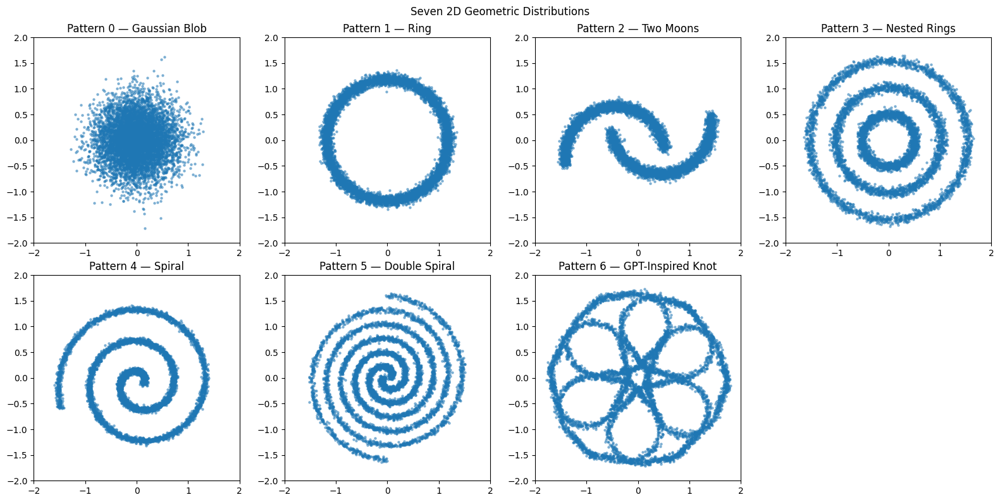

In [73]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for class_id, name in enumerate(PATTERN_NAMES):
    mask = all_labels == class_id
    axes[class_id].scatter(
        all_points[mask, 0],
        all_points[mask, 1],
        s=5,
        alpha=0.45,
    )
    axes[class_id].set_title(name)
    axes[class_id].set_aspect("equal")
    axes[class_id].set_xlim(-2.0, 2.0)
    axes[class_id].set_ylim(-2.0, 2.0)

axes[-1].axis("off")
fig.suptitle("Seven 2D Geometric Distributions")
plt.tight_layout()
plt.show()


A second view samples a smaller number of points from each class. This makes local structure easier to inspect.


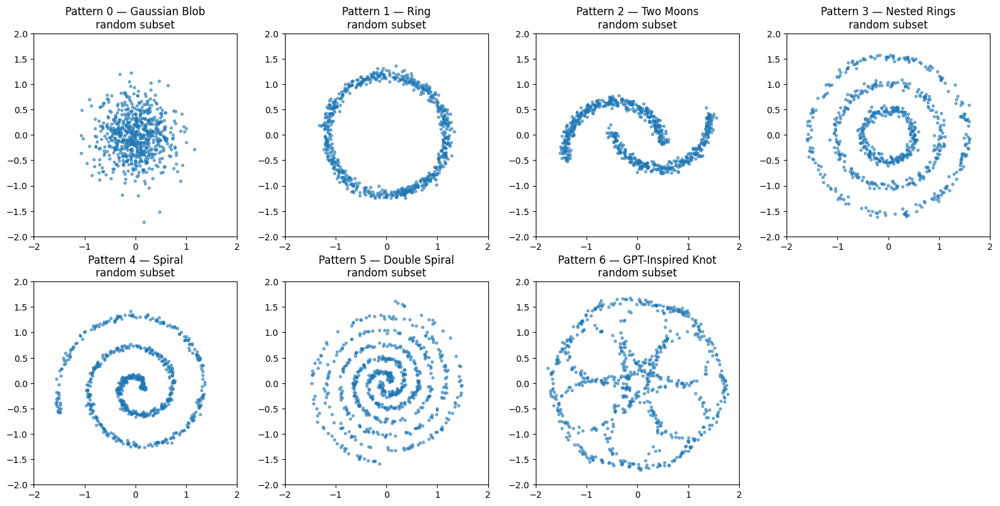

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
rng = np.random.default_rng(123)

for class_id, name in enumerate(PATTERN_NAMES):
    mask = np.flatnonzero(all_labels == class_id)
    chosen = rng.choice(mask, size=min(700, len(mask)), replace=False)

    axes[class_id].scatter(
        all_points[chosen, 0],
        all_points[chosen, 1],
        s=8,
        alpha=0.55,
    )
    axes[class_id].set_title(f"{name}\nrandom subset")
    axes[class_id].set_aspect("equal")
    axes[class_id].set_xlim(-2.0, 2.0)
    axes[class_id].set_ylim(-2.0, 2.0)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 03 — Geometry Before Diffusion

Before training anything, identify what makes the classes increasingly difficult:

| Pattern | Geometric structure |
|---|---|
| Gaussian Blob | simple unimodal density |
| Ring | one-dimensional manifold in $\mathbb{R}^2$ |
| Two Moons | interleaved, non-convex manifolds |
| Nested Rings | multiple spatial scales |
| Spiral | strong nonlinear curvature |
| Double Spiral | multiple intertwined trajectories |
| GPT-Inspired Knot | several local curves plus global interlocking structure |

The diffusion model is **not** asked to memorize a coordinate table. It is learning a conditional probability distribution

$$
p_\theta(x\mid y)
$$

over 2D space.


## 04 — Train / Validation / Test

We split every class independently so all three subsets remain balanced.

Each dataset item returns

```python
x0
label
```

with

```python
x0.shape == [2]
```

and an integer class label.


In [75]:
def balanced_train_val_test_split(points, labels, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = np.random.default_rng(seed)

    train_indices = []
    val_indices = []
    test_indices = []

    for class_id in range(NUM_CLASSES):
        indices = np.flatnonzero(labels == class_id)
        rng.shuffle(indices)

        n = len(indices)
        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)

        train_indices.append(indices[:n_train])
        val_indices.append(indices[n_train:n_train + n_val])
        test_indices.append(indices[n_train + n_val:])

    return (
        np.concatenate(train_indices),
        np.concatenate(val_indices),
        np.concatenate(test_indices),
    )


train_idx, val_idx, test_idx = balanced_train_val_test_split(
    all_points,
    all_labels,
)

train_points, train_labels = all_points[train_idx], all_labels[train_idx]
val_points, val_labels = all_points[val_idx], all_labels[val_idx]
test_points, test_labels = all_points[test_idx], all_labels[test_idx]

print("Train:", train_points.shape)
print("Validation:", val_points.shape)
print("Test:", test_points.shape)


Train: (34300, 2)
Validation: (7350, 2)
Test: (7350, 2)


In [76]:
class Synthetic2DPatternDataset(Dataset):
    def __init__(self, points, labels):
        self.points = torch.as_tensor(points, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.points)

    def __getitem__(self, index):
        return self.points[index], self.labels[index]


train_dataset = Synthetic2DPatternDataset(train_points, train_labels)
val_dataset = Synthetic2DPatternDataset(val_points, val_labels)
test_dataset = Synthetic2DPatternDataset(test_points, test_labels)

BATCH_SIZE = 512 if DEVICE.type == "cuda" else 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

example_x, example_y = train_dataset[0]

print("Single point shape:", example_x.shape)
print("Single label shape:", example_y.shape)
print("Coordinate range:", train_points.min(), "to", train_points.max())
print("Number of classes:", NUM_CLASSES)
print("Device:", DEVICE)


Single point shape: torch.Size([2])
Single label shape: torch.Size([])
Coordinate range: -1.7779703 to 1.7747082
Number of classes: 7
Device: cuda


## 05 — Forward Diffusion in 2D

Notebook 07 already derived the forward process. Here we reuse exactly the same closed-form equation:

$$
x_t =
\sqrt{\bar\alpha_t}x_0
+
\sqrt{1-\bar\alpha_t}\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I_2).
$$

The only new idea is visual: because $x_0$ is now a 2D coordinate, we can watch geometry disappear.


In [77]:
# A cosine schedule keeps useful signal for a while,
# then gradually pushes alpha_bar close to zero.

T = 500
COSINE_S = 0.008


def cosine_beta_schedule(T, s=0.008):
    steps = T + 1

    x = torch.linspace(
        0,
        T,
        steps,
        dtype=torch.float32,
    )

    alpha_bars = torch.cos(
        (
            (x / T) + s
        ) / (1.0 + s)
        * math.pi
        / 2.0
    ) ** 2

    alpha_bars = alpha_bars / alpha_bars[0]

    betas = 1.0 - (
        alpha_bars[1:] / alpha_bars[:-1]
    )

    return torch.clamp(
        betas,
        min=1e-5,
        max=0.999,
    )


betas = cosine_beta_schedule(T).to(DEVICE)

alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(
    1.0 - alpha_bars
)

posterior_variance = torch.zeros_like(betas)

posterior_variance[1:] = (
    betas[1:]
    * (1.0 - alpha_bars[:-1])
    / (1.0 - alpha_bars[1:])
)

diffusion = {
    "T": T,
    "betas": betas,
    "alphas": alphas,
    "alpha_bars": alpha_bars,
    "sqrt_alpha_bars": sqrt_alpha_bars,
    "sqrt_one_minus_alpha_bars": sqrt_one_minus_alpha_bars,
    "posterior_variance": posterior_variance,
}

print("T =", T)
print(
    "alpha_bar[0]  =",
    alpha_bars[0].item(),
)
print(
    "alpha_bar[-1] =",
    alpha_bars[-1].item(),
)

T = 500
alpha_bar[0]  = 0.9999126195907593
alpha_bar[-1] = 9.714311133279807e-09


In [78]:
def extract(schedule_tensor, t, x_shape):
    values = schedule_tensor[t]
    return values.view(-1, *([1] * (len(x_shape) - 1)))


def q_sample(x0, t, schedule, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ab = extract(
        schedule["sqrt_alpha_bars"],
        t,
        x0.shape,
    )
    sqrt_1mab = extract(
        schedule["sqrt_one_minus_alpha_bars"],
        t,
        x0.shape,
    )

    xt = sqrt_ab * x0 + sqrt_1mab * noise
    return xt


Take a single ring and use the **same underlying clean points** at several timesteps.

This makes the progression

```text
Clean Geometry
      ↓
Geometry + Noise
      ↓
Weak Structure
      ↓
Almost Gaussian
      ↓
Pure Noise
```

visually explicit.


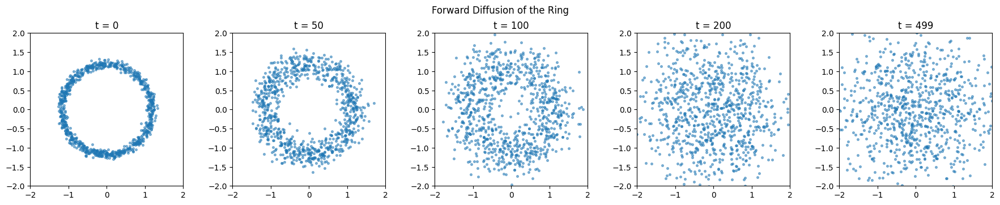

In [79]:
@torch.no_grad()
def plot_forward_diffusion_example(
    class_id=1,
    timesteps=(0, 50, 100, 200, T - 1),
    n_points=900,
):
    points = test_points[test_labels == class_id]
    points = points[:n_points]

    x0 = torch.as_tensor(points, dtype=torch.float32, device=DEVICE)
    noise = torch.randn_like(x0)

    fig, axes = plt.subplots(1, len(timesteps), figsize=(18, 3.5))

    for ax, timestep in zip(axes, timesteps):
        t = torch.full(
            (len(x0),),
            timestep,
            dtype=torch.long,
            device=DEVICE,
        )
        xt = q_sample(x0, t, diffusion, noise=noise)

        ax.scatter(
            xt[:, 0].cpu(),
            xt[:, 1].cpu(),
            s=7,
            alpha=0.5,
        )
        ax.set_title(f"t = {timestep}")
        ax.set_aspect("equal")
        ax.set_xlim(-2.0, 2.0)
        ax.set_ylim(-2.0, 2.0)

    fig.suptitle("Forward Diffusion of the Ring")
    plt.tight_layout()
    plt.show()


plot_forward_diffusion_example()


## 06 — Signal-to-Noise Intuition

Two scalar curves summarize the closed-form forward process:

$$
\sqrt{\bar\alpha_t}
$$

measures how strongly the original geometry remains, while

$$
\sqrt{1-\bar\alpha_t}
$$

measures how strongly Gaussian noise contributes.


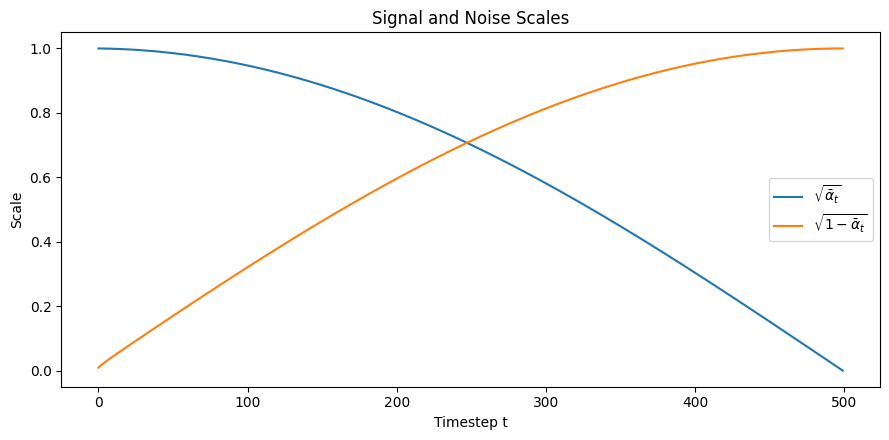

In [80]:
timesteps = np.arange(T)

plt.figure(figsize=(9, 4.5))
plt.plot(
    timesteps,
    sqrt_alpha_bars.cpu(),
    label=r"$\sqrt{\bar{\alpha}_t}$",
)
plt.plot(
    timesteps,
    sqrt_one_minus_alpha_bars.cpu(),
    label=r"$\sqrt{1-\bar{\alpha}_t}$",
)
plt.xlabel("Timestep t")
plt.ylabel("Scale")
plt.title("Signal and Noise Scales")
plt.legend()
plt.tight_layout()
plt.show()


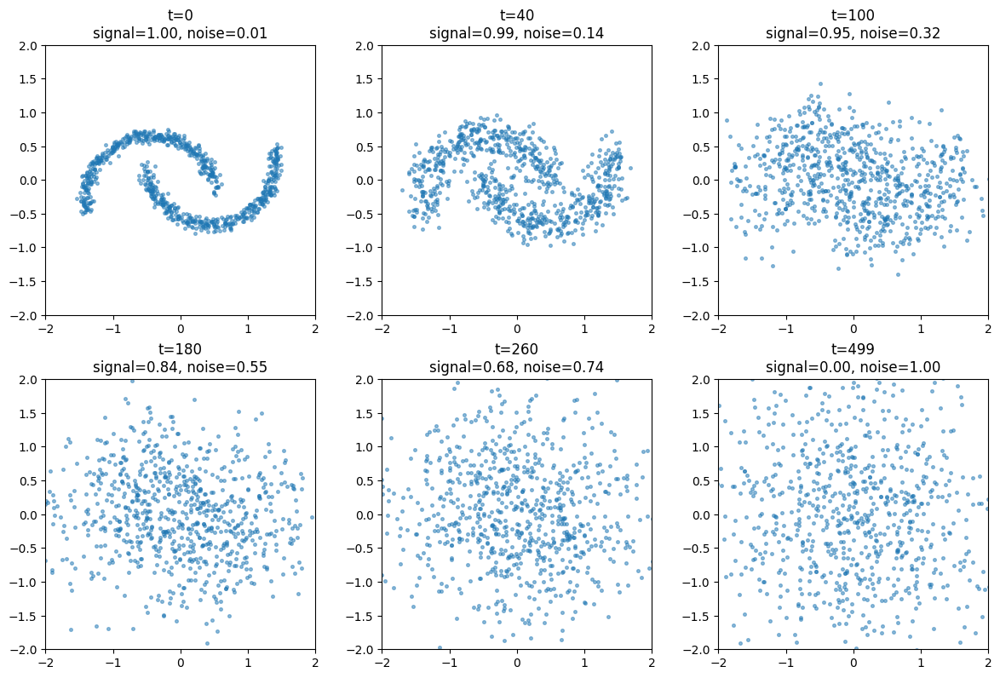

In [81]:
@torch.no_grad()
def plot_noise_levels(class_id=2):
    points = test_points[test_labels == class_id][:800]
    x0 = torch.as_tensor(points, dtype=torch.float32, device=DEVICE)
    noise = torch.randn_like(x0)

    chosen_t = [0, 40, 100, 180, 260, T - 1]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for ax, timestep in zip(axes, chosen_t):
        t = torch.full(
            (len(x0),),
            timestep,
            dtype=torch.long,
            device=DEVICE,
        )
        xt = q_sample(x0, t, diffusion, noise=noise)

        ax.scatter(
            xt[:, 0].cpu(),
            xt[:, 1].cpu(),
            s=7,
            alpha=0.48,
        )
        ax.set_title(
            f"t={timestep}\n"
            f"signal={sqrt_alpha_bars[timestep].item():.2f}, "
            f"noise={sqrt_one_minus_alpha_bars[timestep].item():.2f}"
        )
        ax.set_aspect("equal")
        ax.set_xlim(-2.0, 2.0)
        ax.set_ylim(-2.0, 2.0)

    plt.tight_layout()
    plt.show()


plot_noise_levels()


## 07 — Conditional Diffusion Model

The model receives three things:

$$
x_t\in\mathbb{R}^2,
\qquad
t,
\qquad
y\in\{0,\ldots,6\}.
$$

It predicts

$$
\epsilon_\theta(x_t,t,y)\in\mathbb{R}^2.
$$

The architecture is deliberately small:

```text
x_t ───────────────┐
                   │
time embedding ────┼──> MLP ───> predicted noise
                   │
class embedding ──┘
```

The time embedding is sinusoidal, while the pattern label uses a trainable `nn.Embedding`.


In [82]:
import copy


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2

        frequencies = torch.exp(
            -math.log(10000.0)
            * torch.arange(
                half,
                device=t.device,
                dtype=torch.float32,
            )
            / max(half - 1, 1)
        )

        angles = (
            t.float().unsqueeze(1)
            * frequencies.unsqueeze(0)
        )

        embedding = torch.cat(
            [
                torch.sin(angles),
                torch.cos(angles),
            ],
            dim=1,
        )

        if self.dim % 2 == 1:
            embedding = F.pad(
                embedding,
                (0, 1),
            )

        return embedding


class FourierFeatures2D(nn.Module):
    """
    Random Fourier features give the MLP a richer representation
    of spatial geometry.

    Instead of asking the MLP to learn complex curves directly from
    raw (x, y), we provide multiple sinusoidal spatial frequencies.
    """

    def __init__(
        self,
        num_features=64,
        scale=2.5,
    ):
        super().__init__()

        B = torch.randn(
            2,
            num_features,
        ) * scale

        self.register_buffer(
            "B",
            B,
        )

    def forward(self, x):
        projection = 2.0 * math.pi * (x @ self.B)

        return torch.cat(
            [
                torch.sin(projection),
                torch.cos(projection),
            ],
            dim=1,
        )


class ResidualFiLMBlock(nn.Module):
    """
    Residual block whose hidden representation is modulated
    by time + class conditioning.

    FiLM:
        h' = h * (1 + scale) + shift
    """

    def __init__(
        self,
        hidden_dim,
        condition_dim,
    ):
        super().__init__()

        self.norm = nn.LayerNorm(
            hidden_dim
        )

        self.fc1 = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

        self.fc2 = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

        self.condition_projection = nn.Linear(
            condition_dim,
            2 * hidden_dim,
        )

        self.activation = nn.SiLU()

    def forward(
        self,
        x,
        condition,
    ):
        residual = x

        h = self.norm(x)

        film = self.condition_projection(
            condition
        )

        scale, shift = film.chunk(
            2,
            dim=1,
        )

        h = h * (1.0 + scale) + shift

        h = self.fc1(h)
        h = self.activation(h)

        h = self.fc2(h)

        return residual + h


class ConditionalDiffusionMLP(
    nn.Module
):
    def __init__(
        self,
        num_classes,
        time_dim=128,
        class_dim=64,
        hidden_dim=256,
        condition_dim=256,
        fourier_features=64,
        num_blocks=8,
    ):
        super().__init__()

        self.time_embedding = (
            SinusoidalTimeEmbedding(time_dim)
        )

        self.class_embedding = nn.Embedding(
            num_classes,
            class_dim,
        )

        self.spatial_embedding = (
            FourierFeatures2D(
                num_features=fourier_features,
                scale=2.5,
            )
        )

        spatial_dim = (
            2 * fourier_features
        )

        self.input_projection = nn.Sequential(
            nn.Linear(
                2 + spatial_dim,
                hidden_dim,
            ),
            nn.SiLU(),
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
        )

        self.condition_projection = nn.Sequential(
            nn.Linear(
                time_dim + class_dim,
                condition_dim,
            ),
            nn.SiLU(),
            nn.Linear(
                condition_dim,
                condition_dim,
            ),
        )

        self.blocks = nn.ModuleList(
            [
                ResidualFiLMBlock(
                    hidden_dim=hidden_dim,
                    condition_dim=condition_dim,
                )
                for _ in range(num_blocks)
            ]
        )

        self.output_norm = nn.LayerNorm(
            hidden_dim
        )

        self.output_projection = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.SiLU(),
            nn.Linear(
                hidden_dim,
                2,
            ),
        )

    def forward(
        self,
        x_t,
        t,
        y,
    ):
        # Spatial representation.
        spatial_features = (
            self.spatial_embedding(x_t)
        )

        x_input = torch.cat(
            [
                x_t,
                spatial_features,
            ],
            dim=1,
        )

        h = self.input_projection(
            x_input
        )

        # Time + class conditioning.
        time_features = (
            self.time_embedding(t)
        )

        class_features = (
            self.class_embedding(y)
        )

        condition = torch.cat(
            [
                time_features,
                class_features,
            ],
            dim=1,
        )

        condition = (
            self.condition_projection(
                condition
            )
        )

        # Deep residual processing.
        for block in self.blocks:
            h = block(
                h,
                condition,
            )

        h = self.output_norm(h)

        return self.output_projection(h)


model = ConditionalDiffusionMLP(
    num_classes=NUM_CLASSES,
    time_dim=128,
    class_dim=64,
    hidden_dim=256,
    condition_dim=256,
    fourier_features=64,
    num_blocks=8,
).to(DEVICE)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

print(model)
print()
print(
    f"Trainable parameters: "
    f"{parameter_count:,}"
)

ConditionalDiffusionMLP(
  (time_embedding): SinusoidalTimeEmbedding()
  (class_embedding): Embedding(7, 64)
  (spatial_embedding): FourierFeatures2D()
  (input_projection): Sequential(
    (0): Linear(in_features=130, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (condition_projection): Sequential(
    (0): Linear(in_features=192, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (blocks): ModuleList(
    (0-7): 8 x ResidualFiLMBlock(
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=256, out_features=256, bias=True)
      (fc2): Linear(in_features=256, out_features=256, bias=True)
      (condition_projection): Linear(in_features=256, out_features=512, bias=True)
      (activation): SiLU()
    )
  )
  (output_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output_projection): Sequential(
    

## 08 — DDPM Training

The standard simplified DDPM objective is

$$
\boxed{
L_{\mathrm{simple}}
=
\mathbb{E}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t,y)
\right\|^2
\right]
}.
$$

The training loop is:

```text
sample x0
   ↓
sample class y
   ↓
sample timestep t
   ↓
sample Gaussian noise ε
   ↓
construct xt
   ↓
predict ε
   ↓
MSE(ε, ε̂)
   ↓
backpropagation
```

We train the same network across all seven classes.


In [83]:
def diffusion_loss(model, x0, labels, schedule):
    batch_size = x0.shape[0]

    t = torch.randint(
        low=0,
        high=schedule["T"],
        size=(batch_size,),
        device=x0.device,
        dtype=torch.long,
    )

    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, schedule, noise=noise)

    predicted_noise = model(xt, t, labels)
    loss = F.mse_loss(predicted_noise, noise)

    return loss


In [ ]:
def run_epoch(model, loader, schedule, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_count = 0

    iterator = tqdm(
        loader,
        leave=False,
        desc="train" if training else "val",
    )

    for x0, labels in iterator:
        x0 = x0.to(DEVICE)
        labels = labels.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        loss = diffusion_loss(
            model,
            x0,
            labels,
            schedule,
        )

        if training:
            loss.backward()
            optimizer.step()

        batch_size = len(x0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / total_count


LEARNING_RATE = 2e-3

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

best_val_loss = float("inf")
history = {
    "train": [],
    "val": [],
}

checkpoint_path = ARTIFACT_DIR / "best_diffusion_2d.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(
        model,
        train_loader,
        diffusion,
        optimizer=optimizer,
    )
    val_loss = run_epoch(
        model,
        val_loader,
        diffusion,
        optimizer=None,
    )

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train={train_loss:.6f} | "
        f"val={val_loss:.6f}"
    )

print("Best checkpoint:", checkpoint_path)


train:   0%|          | 0/66 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/140 | train=0.589933 | val=0.423929


train:   0%|          | 0/66 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

...

Epoch 101/140 | train=0.368268 | val=0.372720


train:   0%|          | 0/66 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 102/140 | train=0.367484 | val=0.369352


train:   0%|          | 0/66 [00:00<?, ?it/s]

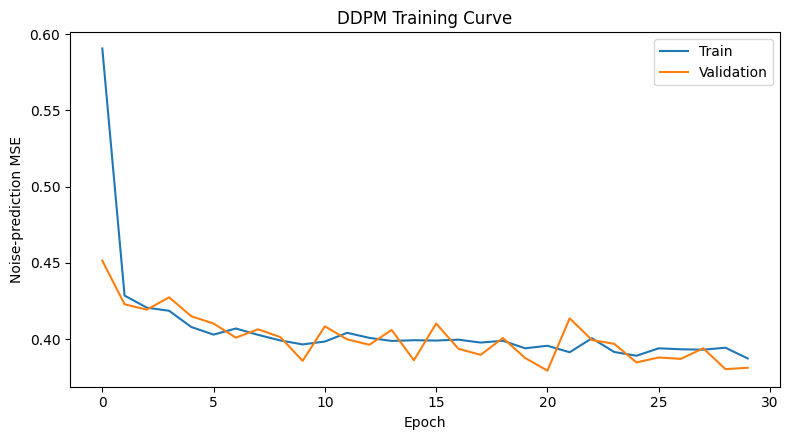

In [ ]:
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()

plt.figure(figsize=(8, 4.5))
plt.plot(history["train"], label="Train")
plt.plot(history["val"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Noise-prediction MSE")
plt.title("DDPM Training Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 09 — First Test: Noise Prediction

Before sampling from scratch, test the actual supervised target of the DDPM.

For a known noisy point cloud we know the injected $\epsilon$. The network produces $\hat\epsilon$.

The question is therefore:

$$
(x_t,t,y)\longrightarrow\epsilon.
$$

This is the learned denoising signal that later drives reverse diffusion.


In [ ]:
@torch.no_grad()
def evaluate_noise_prediction(model, n_points=400, class_id=4, timestep=180):
    class_points = test_points[test_labels == class_id]
    points = class_points[:n_points]

    x0 = torch.as_tensor(points, dtype=torch.float32, device=DEVICE)
    labels = torch.full(
        (len(x0),),
        class_id,
        dtype=torch.long,
        device=DEVICE,
    )
    t = torch.full(
        (len(x0),),
        timestep,
        dtype=torch.long,
        device=DEVICE,
    )

    true_noise = torch.randn_like(x0)
    xt = q_sample(x0, t, diffusion, noise=true_noise)
    predicted_noise = model(xt, t, labels)

    mse = F.mse_loss(predicted_noise, true_noise).item()

    return x0, xt, true_noise, predicted_noise, mse


x0_noise, xt_noise, true_eps, pred_eps, eps_mse = evaluate_noise_prediction(
    model,
)

print(f"Noise prediction MSE: {eps_mse:.6f}")


Noise prediction MSE: 0.193747


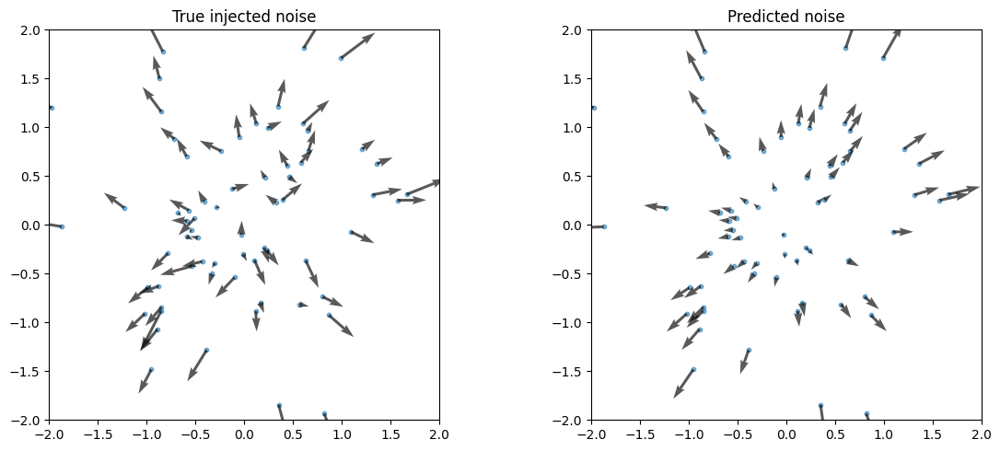

In [ ]:
# A vector-style comparison of true injected noise and predicted noise.

sample_count = 70
base = xt_noise[:sample_count].cpu().numpy()
true_vec = true_eps[:sample_count].cpu().numpy()
pred_vec = pred_eps[:sample_count].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(base[:, 0], base[:, 1], s=10, alpha=0.55)
axes[0].quiver(
    base[:, 0],
    base[:, 1],
    true_vec[:, 0],
    true_vec[:, 1],
    angles="xy",
    scale_units="xy",
    scale=5,
    alpha=0.65,
)
axes[0].set_title("True injected noise")
axes[0].set_aspect("equal")
axes[0].set_xlim(-2.0, 2.0)
axes[0].set_ylim(-2.0, 2.0)

axes[1].scatter(base[:, 0], base[:, 1], s=10, alpha=0.55)
axes[1].quiver(
    base[:, 0],
    base[:, 1],
    pred_vec[:, 0],
    pred_vec[:, 1],
    angles="xy",
    scale_units="xy",
    scale=5,
    alpha=0.65,
)
axes[1].set_title("Predicted noise")
axes[1].set_aspect("equal")
axes[1].set_xlim(-2.0, 2.0)
axes[1].set_ylim(-2.0, 2.0)

plt.tight_layout()
plt.show()


## 10 — Estimate $x_0$

Because the model predicts noise, we can algebraically invert the forward equation:

$$
\boxed{
\hat{x}_0 =
\frac{
x_t
-
\sqrt{1-\bar\alpha_t}\,
\epsilon_\theta(x_t,t,y)
}{
\sqrt{\bar\alpha_t}
}
}.
$$

This is useful because it gives us a direct visual answer to:

> What clean geometry does the model believe is hidden inside this noisy observation?


In [ ]:
def predict_x0_from_noise(x_t, t, predicted_noise, schedule):
    sqrt_ab = extract(
        schedule["sqrt_alpha_bars"],
        t,
        x_t.shape,
    )
    sqrt_1mab = extract(
        schedule["sqrt_one_minus_alpha_bars"],
        t,
        x_t.shape,
    )

    return (
        x_t - sqrt_1mab * predicted_noise
    ) / sqrt_ab


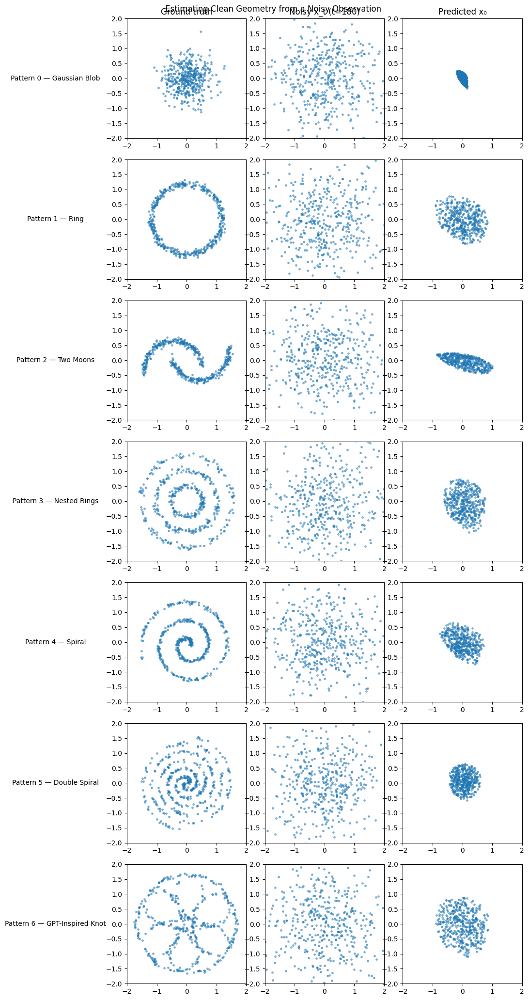

In [ ]:
@torch.no_grad()
def plot_x0_estimates(
    timestep=180,
    points_per_class=450,
):
    fig, axes = plt.subplots(
        NUM_CLASSES,
        3,
        figsize=(11, 3.0 * NUM_CLASSES),
    )

    for class_id in range(NUM_CLASSES):
        class_points = test_points[test_labels == class_id]
        points = class_points[:points_per_class]

        x0 = torch.as_tensor(
            points,
            dtype=torch.float32,
            device=DEVICE,
        )
        labels = torch.full(
            (len(x0),),
            class_id,
            dtype=torch.long,
            device=DEVICE,
        )
        t = torch.full(
            (len(x0),),
            timestep,
            dtype=torch.long,
            device=DEVICE,
        )

        noise = torch.randn_like(x0)
        xt = q_sample(
            x0,
            t,
            diffusion,
            noise=noise,
        )
        eps_hat = model(xt, t, labels)
        x0_hat = predict_x0_from_noise(
            xt,
            t,
            eps_hat,
            diffusion,
        )

        clouds = [
            x0.detach().cpu().numpy(),
            xt.detach().cpu().numpy(),
            x0_hat.detach().cpu().numpy(),
        ]
        titles = [
            "Ground truth",
            f"Noisy x_t (t={timestep})",
            "Predicted x₀",
        ]

        for col in range(3):
            axes[class_id, col].scatter(
                clouds[col][:, 0],
                clouds[col][:, 1],
                s=6,
                alpha=0.5,
            )
            axes[class_id, col].set_aspect("equal")
            axes[class_id, col].set_xlim(-2.0, 2.0)
            axes[class_id, col].set_ylim(-2.0, 2.0)

            if class_id == 0:
                axes[class_id, col].set_title(titles[col])

        axes[class_id, 0].set_ylabel(
            PATTERN_NAMES[class_id],
            rotation=0,
            labelpad=75,
            va="center",
        )

    fig.suptitle("Estimating Clean Geometry from a Noisy Observation")
    plt.tight_layout()
    plt.show()


plot_x0_estimates()


## 11 — Reverse Diffusion Step

The DDPM reverse mean from Notebook 07 is

$$
\mu_\theta(x_t,t,y)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}
{\sqrt{1-\bar\alpha_t}}
\epsilon_\theta(x_t,t,y)
\right).
$$

The posterior variance is

$$
\tilde\beta_t
=
\beta_t
\frac{1-\bar\alpha_{t-1}}
{1-\bar\alpha_t}.
$$

For $t>0$,

$$
x_{t-1}
=
\mu_\theta
+
\sqrt{\tilde\beta_t}\,z,
\qquad
z\sim\mathcal{N}(0,I).
$$

We implement the step directly rather than using a diffusion library.


In [ ]:
@torch.no_grad()
def posterior_mean(x_t, t, predicted_noise, schedule):
    beta_t = extract(
        schedule["betas"],
        t,
        x_t.shape,
    )
    alpha_t = extract(
        schedule["alphas"],
        t,
        x_t.shape,
    )
    sqrt_one_minus_ab = extract(
        schedule["sqrt_one_minus_alpha_bars"],
        t,
        x_t.shape,
    )

    return (
        1.0 / torch.sqrt(alpha_t)
    ) * (
        x_t
        - (beta_t / sqrt_one_minus_ab) * predicted_noise
    )


@torch.no_grad()
def p_sample_step(model, x_t, t, labels, schedule):
    predicted_noise = model(x_t, t, labels)

    mean = posterior_mean(
        x_t,
        t,
        predicted_noise,
        schedule,
    )

    variance = extract(
        schedule["posterior_variance"],
        t,
        x_t.shape,
    )

    noise = torch.randn_like(x_t)

    return mean + torch.sqrt(
        torch.clamp(variance, min=0.0)
    ) * noise


The sampler starts from

$$
x_{T-1}\sim\mathcal{N}(0,I_2)
$$

and repeatedly applies the learned reverse step.

The `trajectory` returned by `sample` stores every reverse timestep so that the process can be animated later.


In [ ]:
@torch.no_grad()
def sample(
    model,
    schedule,
    labels,
    initial_noise=None,
):
    model.eval()

    if initial_noise is None:
        x = torch.randn(
            len(labels),
            2,
            device=DEVICE,
        )
    else:
        x = initial_noise.to(DEVICE).clone()

    trajectory = [
        (schedule["T"] - 1, x.detach().cpu().clone())
    ]

    for timestep in reversed(range(1, schedule["T"])):
        t = torch.full(
            (len(labels),),
            timestep,
            dtype=torch.long,
            device=DEVICE,
        )

        x = p_sample_step(
            model,
            x,
            t,
            labels,
            schedule,
        )

        trajectory.append(
            (timestep - 1, x.detach().cpu().clone())
        )

    return x, trajectory


## 12 — THE MAIN EXPERIMENT

Now we generate all seven classes from fresh Gaussian noise.

For each class:

1. draw $x_{T-1}\sim\mathcal{N}(0,I)$,
2. fix the desired class label $y$,
3. repeatedly predict noise,
4. move one reverse step,
5. save the entire trajectory.

The expected visual progression is:

```text
Gaussian Noise
       ↓
reverse steps
       ↓
rough geometry
       ↓
recognizable geometry
       ↓
final pattern
```


In [ ]:
@torch.no_grad()
def generate_main_experiment(
    points_per_class=800,
):
    generated = {}
    trajectories = {}

    for class_id in range(NUM_CLASSES):
        labels = torch.full(
            (points_per_class,),
            class_id,
            dtype=torch.long,
            device=DEVICE,
        )

        final_points, trajectory = sample(
            model,
            diffusion,
            labels,
        )

        generated[class_id] = final_points.cpu()
        trajectories[class_id] = trajectory

        print(
            f"{PATTERN_NAMES[class_id]}: "
            f"{final_points.shape}"
        )

    return generated, trajectories


generated_by_class, trajectories_by_class = generate_main_experiment()


Pattern 0 — Gaussian Blob: torch.Size([800, 2])
Pattern 1 — Ring: torch.Size([800, 2])
Pattern 2 — Two Moons: torch.Size([800, 2])
Pattern 3 — Nested Rings: torch.Size([800, 2])
Pattern 4 — Spiral: torch.Size([800, 2])
Pattern 5 — Double Spiral: torch.Size([800, 2])
Pattern 6 — GPT-Inspired Knot: torch.Size([800, 2])


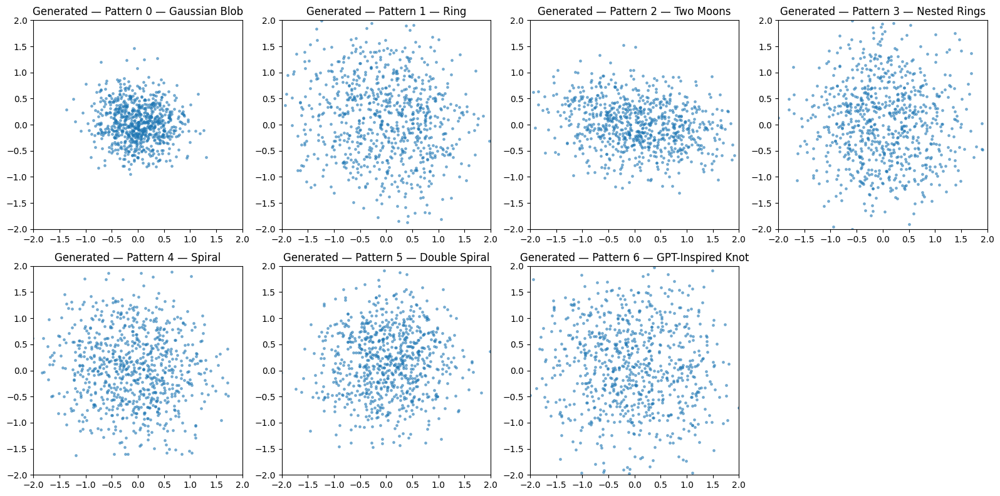

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for class_id, name in enumerate(PATTERN_NAMES):
    generated = generated_by_class[class_id].numpy()

    axes[class_id].scatter(
        generated[:, 0],
        generated[:, 1],
        s=6,
        alpha=0.5,
    )
    axes[class_id].set_title(f"Generated — {name}")
    axes[class_id].set_aspect("equal")
    axes[class_id].set_xlim(-2.0, 2.0)
    axes[class_id].set_ylim(-2.0, 2.0)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 13 — Reverse Diffusion GIFs

The animation uses the actual saved reverse trajectory.

The axis limits are kept fixed for every frame so the geometry does not appear to move because of rescaling.


In [ ]:
def make_reverse_gif(
    trajectory,
    class_name,
    save_path,
    frame_stride=5,
    point_size=8,
):
    selected = trajectory[::frame_stride]

    if selected[-1][0] != trajectory[-1][0]:
        selected.append(trajectory[-1])

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    first_t, first_points = selected[0]
    scatter = ax.scatter(
        first_points[:, 0],
        first_points[:, 1],
        s=point_size,
        alpha=0.55,
    )

    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def update(frame_index):
        timestep, points = selected[frame_index]
        scatter.set_offsets(points.numpy())
        ax.set_title(
            f"Reverse Diffusion — t = {timestep}\n{class_name}"
        )
        return (scatter,)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(selected),
        interval=90,
        blit=True,
        repeat=False,
    )

    animation.save(
        save_path,
        writer=PillowWriter(fps=12),
    )
    plt.close(fig)

    return save_path


In [ ]:
gif_paths = []

for class_id, name in enumerate(PATTERN_NAMES):
    filename_map = {
        0: "pattern_00_blob.gif",
        1: "pattern_01_ring.gif",
        2: "pattern_02_moons.gif",
        3: "pattern_03_nested_rings.gif",
        4: "pattern_04_spiral.gif",
        5: "pattern_05_double_spiral.gif",
        6: "pattern_06_gpt_knot.gif",
    }

    path = ARTIFACT_DIR / filename_map[class_id]

    make_reverse_gif(
        trajectories_by_class[class_id],
        name,
        path,
        frame_stride=5,
        point_size=8,
    )

    gif_paths.append(path)
    print(path)


artifacts\pattern_00_blob.gif
artifacts\pattern_01_ring.gif
artifacts\pattern_02_moons.gif
artifacts\pattern_03_nested_rings.gif
artifacts\pattern_04_spiral.gif
artifacts\pattern_05_double_spiral.gif
artifacts\pattern_06_gpt_knot.gif


### Display the seven generated GIFs


pattern_00_blob.gif


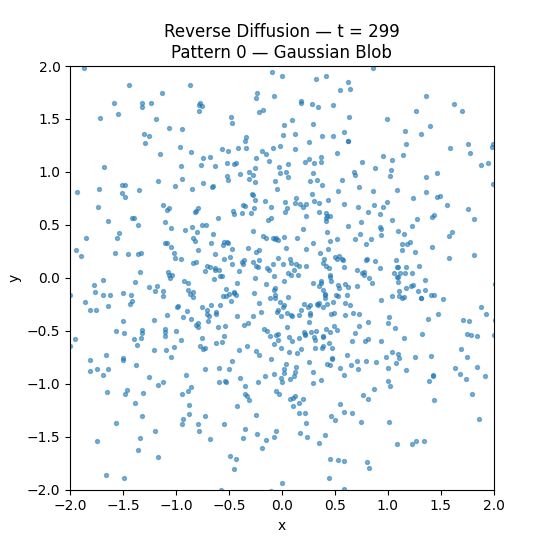

pattern_01_ring.gif


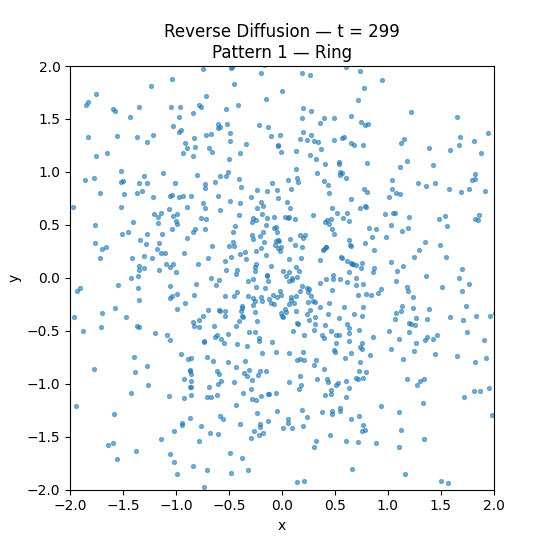

pattern_02_moons.gif


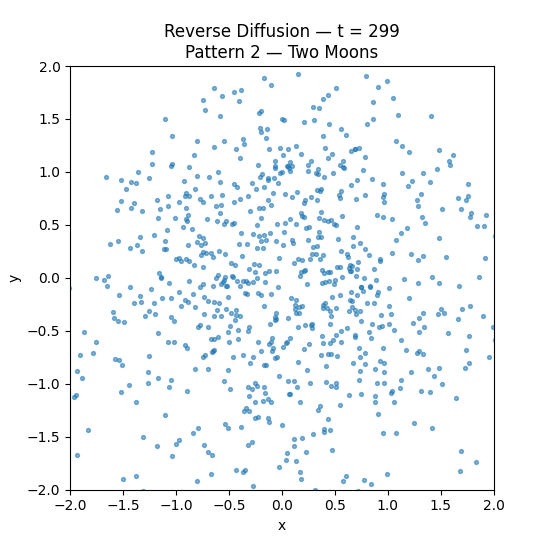

pattern_03_nested_rings.gif


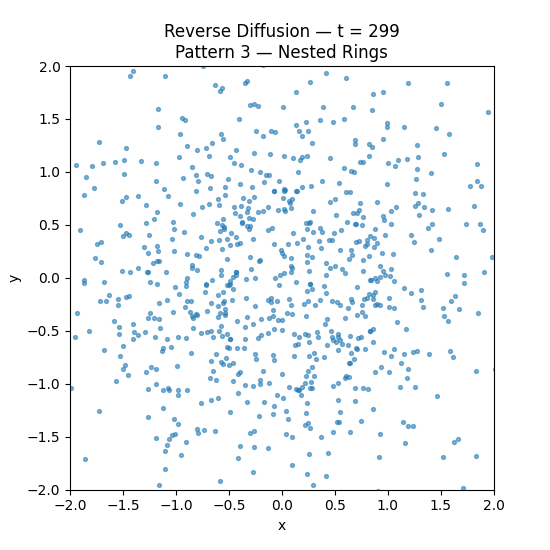

pattern_04_spiral.gif


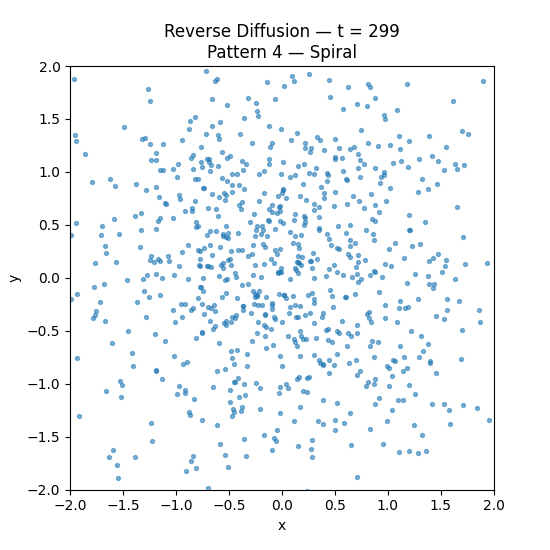

pattern_05_double_spiral.gif


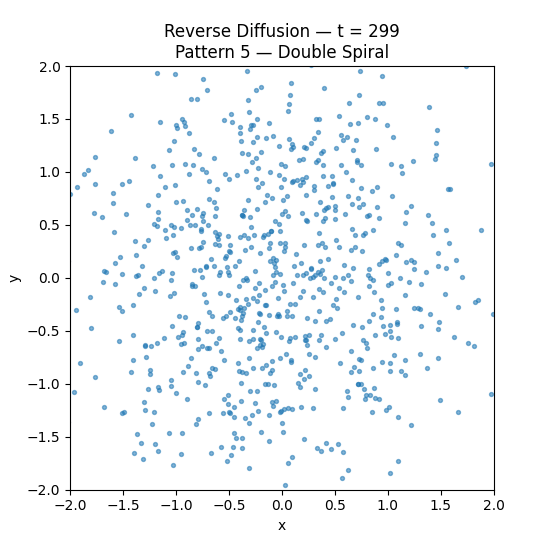

pattern_06_gpt_knot.gif


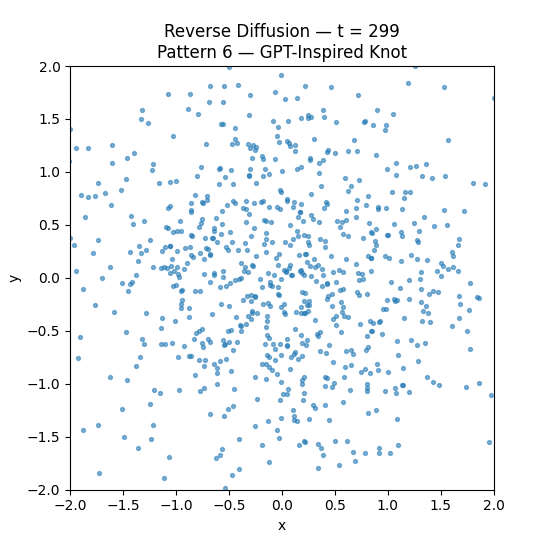

In [ ]:
for path in gif_paths:
    print(path.name)
    display(IPyImage(filename=str(path)))


## 14 — Combined Reverse-Diffusion GIF

Now use the same initial Gaussian noise for all seven conditions.

The only thing that changes between panels is the class embedding.


artifacts\all_patterns_reverse_diffusion.gif


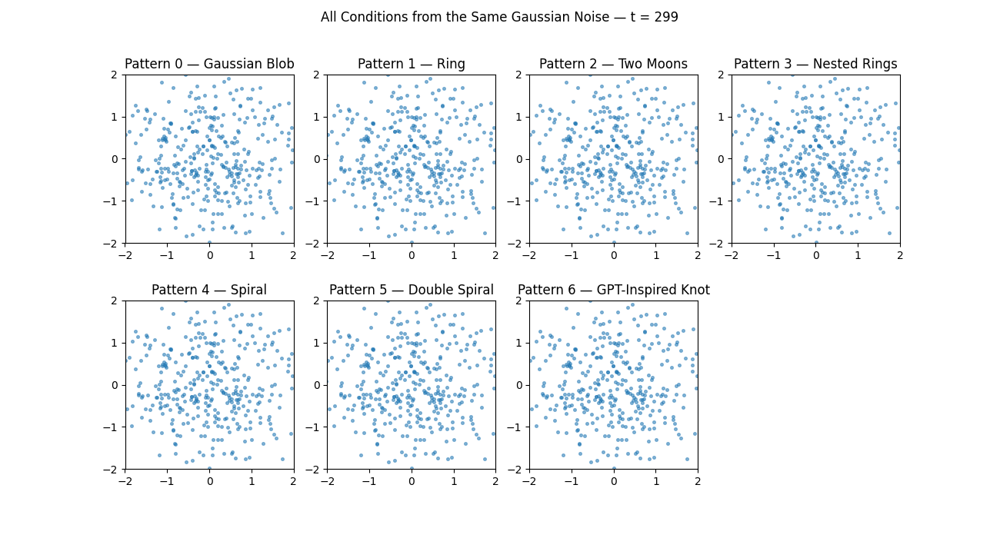

In [ ]:
def make_combined_reverse_gif(
    model,
    schedule,
    save_path,
    points_per_class=400,
    frame_stride=5,
    seed=1234,
):
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)

    shared_noise = torch.randn(
        points_per_class,
        2,
        generator=generator,
        device=DEVICE,
    )

    x = shared_noise.repeat(NUM_CLASSES, 1)

    labels = torch.arange(
        NUM_CLASSES,
        device=DEVICE,
        dtype=torch.long,
    ).repeat_interleave(points_per_class)

    trajectory = [
        (
            schedule["T"] - 1,
            x.detach()
            .view(NUM_CLASSES, points_per_class, 2)
            .cpu()
            .clone(),
        )
    ]

    for timestep in reversed(range(1, schedule["T"])):
        t = torch.full(
            (len(labels),),
            timestep,
            dtype=torch.long,
            device=DEVICE,
        )

        x = p_sample_step(
            model,
            x,
            t,
            labels,
            schedule,
        )

        trajectory.append(
            (
                timestep - 1,
                x.detach()
                .view(NUM_CLASSES, points_per_class, 2)
                .cpu()
                .clone(),
            )
        )

    selected = trajectory[::frame_stride]
    if selected[-1][0] != trajectory[-1][0]:
        selected.append(trajectory[-1])

    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    axes = axes.ravel()

    scatters = []

    for class_id in range(NUM_CLASSES):
        points0 = selected[0][1][class_id].numpy()
        scatter = axes[class_id].scatter(
            points0[:, 0],
            points0[:, 1],
            s=7,
            alpha=0.5,
        )
        scatters.append(scatter)

        axes[class_id].set_title(PATTERN_NAMES[class_id])
        axes[class_id].set_aspect("equal")
        axes[class_id].set_xlim(-2.0, 2.0)
        axes[class_id].set_ylim(-2.0, 2.0)

    axes[-1].axis("off")

    def update(frame_index):
        timestep, frame_points = selected[frame_index]

        for class_id, scatter in enumerate(scatters):
            scatter.set_offsets(
                frame_points[class_id].numpy()
            )

        fig.suptitle(
            f"All Conditions from the Same Gaussian Noise — t = {timestep}"
        )
        return tuple(scatters)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(selected),
        interval=90,
        blit=False,
        repeat=False,
    )

    animation.save(
        save_path,
        writer=PillowWriter(fps=12),
    )
    plt.close(fig)

    return save_path


combined_gif_path = ARTIFACT_DIR / "all_patterns_reverse_diffusion.gif"

make_combined_reverse_gif(
    model,
    diffusion,
    combined_gif_path,
)

print(combined_gif_path)
display(IPyImage(filename=str(combined_gif_path)))


## 15 — Static Reverse Trajectory

The GIF is intuitive, but a static figure is useful for careful mathematical inspection.

For one difficult class we show selected reverse timesteps:

$$
t=T-1,\;0.8T,\;0.6T,\;0.4T,\;0.2T,\;0.
$$


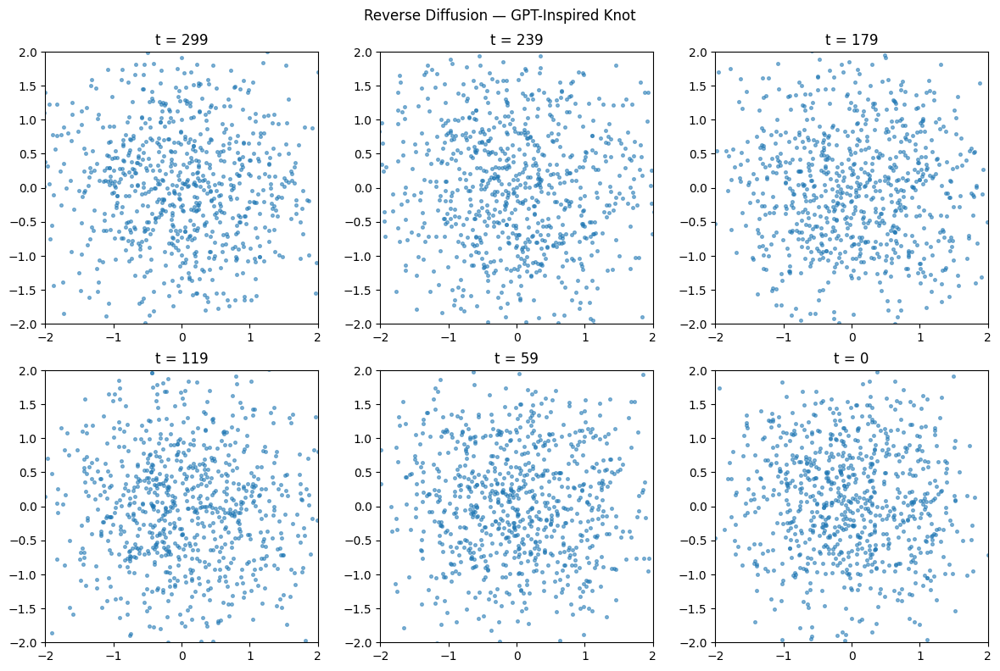

In [ ]:
def trajectory_to_dict(trajectory):
    return {int(t): points for t, points in trajectory}


class_id = 6
trajectory_dict = trajectory_to_dict(
    trajectories_by_class[class_id]
)

selected_t = [
    T - 1,
    int(0.8 * (T - 1)),
    int(0.6 * (T - 1)),
    int(0.4 * (T - 1)),
    int(0.2 * (T - 1)),
    0,
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, timestep in zip(axes, selected_t):
    points = trajectory_dict[timestep].numpy()

    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=7,
        alpha=0.52,
    )
    ax.set_title(f"t = {timestep}")
    ax.set_aspect("equal")
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)

fig.suptitle("Reverse Diffusion — GPT-Inspired Knot")
plt.tight_layout()
plt.show()


## 16 — Easy → Hard Comparison

Each row shows:

```text
Noise
Intermediate
Final
Ground Truth
```

The goal is not to declare a universal difficulty ranking. Instead, inspect how long visible structure remains ambiguous for each learned distribution.


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

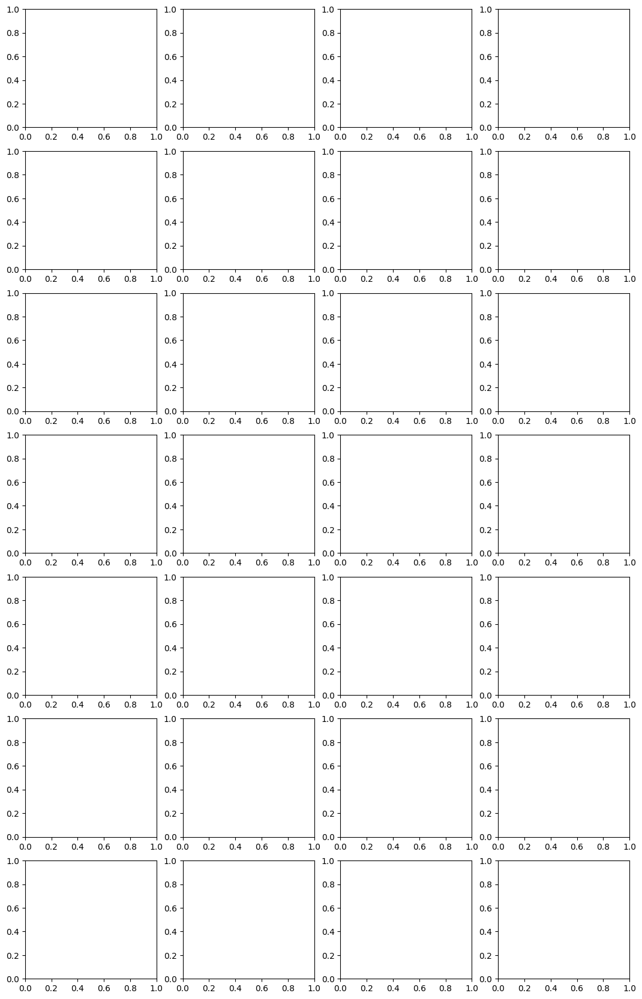

In [ ]:
def find_nearest_timestep(trajectory, target_t):
    return min(
        trajectory,
        key=lambda pair: abs(pair[0] - target_t),
    )


comparison_t = [
    T - 1,
    int(0.55 * (T - 1)),
]

fig, axes = plt.subplots(
    NUM_CLASSES,
    4,
    figsize=(13, 3.0 * NUM_CLASSES),
)

for class_id in range(NUM_CLASSES):
    noise_t, noise_points = find_nearest_timestep(
        trajectories_by_class[class_id],
        comparison_t[0],
    )
    mid_t, mid_points = find_nearest_timestep(
        trajectories_by_class[class_id],
        comparison_t[1],
    )

    final_points = generated_by_class[class_id].numpy()
    truth_points = test_points[test_labels == class_id][:800]

    columns = [
        ("Noise", noise_points.numpy()),
        (f"Intermediate\nt={mid_t}", mid_points.numpy()),
        ("Final", final_points.numpy()),
        ("Ground Truth", truth_points),
    ]

    for col, (title, points) in enumerate(columns):
        axes[class_id, col].scatter(
            points[:, 0],
            points[:, 1],
            s=6,
            alpha=0.5,
        )
        axes[class_id, col].set_aspect("equal")
        axes[class_id, col].set_xlim(-2.0, 2.0)
        axes[class_id, col].set_ylim(-2.0, 2.0)

        if class_id == 0:
            axes[class_id, col].set_title(title)

    axes[class_id, 0].set_ylabel(
        PATTERN_NAMES[class_id],
        rotation=0,
        labelpad=75,
        va="center",
    )

plt.tight_layout()
plt.show()


## 17 — Conditioning Experiment

A single conditional diffusion model can learn several distributions.

The key idea is to keep the **same initial Gaussian cloud** and change only $y$:

$$
p_\theta(x\mid y=0),
\;
p_\theta(x\mid y=1),
\;
\ldots,
\;
p_\theta(x\mid y=6).
$$

If the class embedding is doing its job, the same random starting configuration should be transformed into different geometric distributions.


In [ ]:
@torch.no_grad()
def generate_same_noise_for_all_classes(
    n_points=700,
    seed=2026,
):
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)

    shared_noise = torch.randn(
        n_points,
        2,
        generator=generator,
        device=DEVICE,
    )

    outputs = {}

    for class_id in range(NUM_CLASSES):
        labels = torch.full(
            (n_points,),
            class_id,
            dtype=torch.long,
            device=DEVICE,
        )

        final_points, _ = sample(
            model,
            diffusion,
            labels,
            initial_noise=shared_noise,
        )

        outputs[class_id] = final_points.cpu()

    return shared_noise.cpu(), outputs


shared_noise, same_noise_outputs = generate_same_noise_for_all_classes()


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for class_id in range(NUM_CLASSES):
    points = same_noise_outputs[class_id].numpy()

    axes[class_id].scatter(
        points[:, 0],
        points[:, 1],
        s=7,
        alpha=0.5,
    )
    axes[class_id].set_title(
        f"Same noise → {PATTERN_NAMES[class_id]}"
    )
    axes[class_id].set_aspect("equal")
    axes[class_id].set_xlim(-2.0, 2.0)
    axes[class_id].set_ylim(-2.0, 2.0)

axes[-1].axis("off")
fig.suptitle("Changing Only the Conditioning Label")
plt.tight_layout()
plt.show()


## 18 — Reconstruction / Denoising Experiment

Now use real held-out test points.

For a selected timestep $t$, construct

$$
x_t = q(x_t\mid x_0),
$$

then use the network to estimate

$$
\hat{x}_0.
$$

The point is to distinguish **generation from denoising**:

- generation starts from Gaussian noise,
- denoising starts from a real clean example and tries to recover it.


In [ ]:
@torch.no_grad()
def reconstruction_metrics(
    class_id,
    timestep=160,
    points_per_class=700,
):
    class_points = test_points[test_labels == class_id]
    points = class_points[:points_per_class]

    x0 = torch.as_tensor(
        points,
        dtype=torch.float32,
        device=DEVICE,
    )
    labels = torch.full(
        (len(x0),),
        class_id,
        dtype=torch.long,
        device=DEVICE,
    )
    t = torch.full(
        (len(x0),),
        timestep,
        dtype=torch.long,
        device=DEVICE,
    )

    noise = torch.randn_like(x0)
    xt = q_sample(
        x0,
        t,
        diffusion,
        noise=noise,
    )

    eps_hat = model(
        xt,
        t,
        labels,
    )
    x0_hat = predict_x0_from_noise(
        xt,
        t,
        eps_hat,
        diffusion,
    )

    mse = F.mse_loss(x0_hat, x0).item()

    return (
        x0.cpu(),
        xt.cpu(),
        x0_hat.cpu(),
        mse,
    )


fig, axes = plt.subplots(
    NUM_CLASSES,
    3,
    figsize=(11, 3.0 * NUM_CLASSES),
)

reconstruction_mses = {}

for class_id in range(NUM_CLASSES):
    x0_true, xt_obs, x0_pred, mse = reconstruction_metrics(
        class_id,
        timestep=160,
    )
    reconstruction_mses[class_id] = mse

    clouds = [
        x0_true.numpy(),
        xt_obs.numpy(),
        x0_pred.numpy(),
    ]
    titles = [
        "Ground Truth",
        "Noisy Observation",
        f"Predicted x₀\nMSE={mse:.4f}",
    ]

    for col in range(3):
        axes[class_id, col].scatter(
            clouds[col][:, 0],
            clouds[col][:, 1],
            s=6,
            alpha=0.5,
        )
        axes[class_id, col].set_aspect("equal")
        axes[class_id, col].set_xlim(-2.0, 2.0)
        axes[class_id, col].set_ylim(-2.0, 2.0)

        if class_id == 0:
            axes[class_id, col].set_title(titles[col])

    axes[class_id, 0].set_ylabel(
        PATTERN_NAMES[class_id],
        rotation=0,
        labelpad=75,
        va="center",
    )

plt.tight_layout()
plt.show()

print("Reconstruction MSE by class:")
for class_id, mse in reconstruction_mses.items():
    print(f"{class_id}: {mse:.6f} — {PATTERN_NAMES[class_id]}")


## 19 — Quantitative Evaluation

Two direct measurements are useful here.

### 1. Noise prediction MSE

$$
\frac{1}{N}
\sum_i
\left\|
\epsilon_i-\hat{\epsilon}_i
\right\|^2.
$$

### 2. Reconstruction MSE

$$
\frac{1}{N}
\sum_i
\left\|
x_{0,i}-\hat{x}_{0,i}
\right\|^2.
$$

For **generated** clouds, pointwise MSE is not the right concept because generated points do not have a one-to-one correspondence with the test points.

So we also compute an RBF-kernel MMD on random subsets. This compares distributions rather than matching points by index.


In [ ]:
@torch.no_grad()
def rbf_mmd(x, y, max_points=400):
    x = x.float().to(DEVICE)
    y = y.float().to(DEVICE)

    if len(x) > max_points:
        x = x[:max_points]
    if len(y) > max_points:
        y = y[:max_points]

    xy = torch.cat([x, y], dim=0)

    distances = torch.cdist(
        xy,
        xy,
        p=2,
    )
    positive = distances[distances > 0]

    bandwidth = torch.median(positive)
    bandwidth = torch.clamp(
        bandwidth,
        min=torch.tensor(
            1e-3,
            device=DEVICE,
        ),
    )

    def kernel(a, b):
        dist2 = torch.cdist(a, b, p=2) ** 2
        return torch.exp(
            -dist2 / (2.0 * bandwidth ** 2)
        )

    k_xx = kernel(x, x).mean()
    k_yy = kernel(y, y).mean()
    k_xy = kernel(x, y).mean()

    return (k_xx + k_yy - 2.0 * k_xy).item()


noise_eval_values = []
generated_mmd = {}

for class_id in range(NUM_CLASSES):
    class_mask = test_labels == class_id
    real = torch.as_tensor(
        test_points[class_mask][:900],
        dtype=torch.float32,
    )

    generated = generated_by_class[class_id][:900]

    generated_mmd[class_id] = rbf_mmd(
        real,
        generated,
    )

print("Noise prediction MSE:", eps_mse)
print()
print("Reconstruction MSE:")
for class_id, value in reconstruction_mses.items():
    print(f"  {PATTERN_NAMES[class_id]}: {value:.6f}")

print()
print("RBF-MMD between real test points and generated points:")
for class_id, value in generated_mmd.items():
    print(f"  {PATTERN_NAMES[class_id]}: {value:.6f}")


These measurements should be read carefully.

A lower reconstruction MSE means the model's direct $\hat{x}_0$ estimate is closer to the held-out clean points in Euclidean space.

MMD is different: it asks whether the generated **distribution** resembles the real distribution under an RBF-kernel comparison.

Neither metric by itself is a complete measure of visual generative quality.


## 20 — Visual Failure Cases

A useful diffusion notebook should show imperfect results too.

The following cell identifies the three classes with the largest observed MMD in this run and places the generated distribution next to its ground truth. The interpretation is deliberately empirical: these are the largest discrepancies **in this experiment**, not a universal ranking of pattern difficulty.


In [ ]:
largest_discrepancies = sorted(
    generated_mmd.items(),
    key=lambda item: item[1],
    reverse=True,
)[:3]

fig, axes = plt.subplots(
    len(largest_discrepancies),
    2,
    figsize=(9, 4 * len(largest_discrepancies)),
)

if len(largest_discrepancies) == 1:
    axes = np.array([axes])

for row, (class_id, mmd_value) in enumerate(largest_discrepancies):
    real = test_points[test_labels == class_id][:800]
    generated = generated_by_class[class_id].numpy()

    axes[row, 0].scatter(
        real[:, 0],
        real[:, 1],
        s=6,
        alpha=0.5,
    )
    axes[row, 0].set_title(
        f"Ground Truth — {PATTERN_NAMES[class_id]}"
    )
    axes[row, 0].set_aspect("equal")
    axes[row, 0].set_xlim(-2.0, 2.0)
    axes[row, 0].set_ylim(-2.0, 2.0)

    axes[row, 1].scatter(
        generated[:, 0],
        generated[:, 1],
        s=6,
        alpha=0.5,
    )
    axes[row, 1].set_title(
        f"Generated — MMD={mmd_value:.5f}"
    )
    axes[row, 1].set_aspect("equal")
    axes[row, 1].set_xlim(-2.0, 2.0)
    axes[row, 1].set_ylim(-2.0, 2.0)

plt.tight_layout()
plt.show()


Observed discrepancies can come from several concrete factors visible in the experiment, such as:

- limited MLP capacity,
- limited training time,
- the complexity of the target geometry,
- the chosen diffusion schedule,
- overlap between local regions of different structures.

These are hypotheses to inspect against the actual experiment rather than fixed explanations.


## 21 — Optional Challenge: More Complex GPT Knot

We can perturb the procedural knot without changing its overall family.

This gives a simple out-of-distribution challenge: the network was trained on the original knot generator, while the new cloud has stronger deformation and rotational variation.


In [ ]:
ood_rng = np.random.default_rng(2027)

ood_knot = make_gpt_inspired_knot(
    1400,
    ood_rng,
    loop_count=6,
    deformation=0.10,
    rotation_jitter=0.14,
    coordinate_noise=0.035,
)

# Apply the same global normalization used by the original dataset.
ood_knot = (
    ood_knot
    / np.max(np.abs(ood_knot))
    * 1.78
).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].scatter(
    test_points[test_labels == 6][:900, 0],
    test_points[test_labels == 6][:900, 1],
    s=6,
    alpha=0.5,
)
axes[0].set_title("Training-family GPT-Inspired Knot")
axes[0].set_aspect("equal")
axes[0].set_xlim(-2.0, 2.0)
axes[0].set_ylim(-2.0, 2.0)

axes[1].scatter(
    ood_knot[:, 0],
    ood_knot[:, 1],
    s=6,
    alpha=0.5,
)
axes[1].set_title("More Difficult OOD Knot")
axes[1].set_aspect("equal")
axes[1].set_xlim(-2.0, 2.0)
axes[1].set_ylim(-2.0, 2.0)

plt.tight_layout()
plt.show()


In [ ]:
@torch.no_grad()
def denoise_ood_knot(
    points,
    class_id=6,
    timestep=180,
):
    x0 = torch.as_tensor(
        points,
        dtype=torch.float32,
        device=DEVICE,
    )
    labels = torch.full(
        (len(x0),),
        class_id,
        dtype=torch.long,
        device=DEVICE,
    )
    t = torch.full(
        (len(x0),),
        timestep,
        dtype=torch.long,
        device=DEVICE,
    )

    noise = torch.randn_like(x0)
    xt = q_sample(
        x0,
        t,
        diffusion,
        noise=noise,
    )

    eps_hat = model(
        xt,
        t,
        labels,
    )
    x0_hat = predict_x0_from_noise(
        xt,
        t,
        eps_hat,
        diffusion,
    )

    return (
        x0.cpu(),
        xt.cpu(),
        x0_hat.cpu(),
        F.mse_loss(x0_hat, x0).item(),
    )


ood_true, ood_noisy, ood_pred, ood_mse = denoise_ood_knot(
    ood_knot
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, points, title in zip(
    axes,
    [
        ood_true.numpy(),
        ood_noisy.numpy(),
        ood_pred.numpy(),
    ],
    [
        "OOD Ground Truth",
        "OOD Noisy Observation",
        f"OOD Predicted x₀\nMSE={ood_mse:.5f}",
    ],
):
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=6,
        alpha=0.5,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)

plt.tight_layout()
plt.show()


## 22 — Final Conceptual Connection

Everything in the notebook reduces back to the same DDPM chain from Notebook 07.

### Forward process

$$
x_t
=
\sqrt{\bar\alpha_t}x_0
+
\sqrt{1-\bar\alpha_t}\epsilon.
$$

### Learned noise prediction

$$
\epsilon_\theta(x_t,t,y).
$$

### Clean-data estimate

$$
\hat{x}_0
=
\frac{
x_t
-
\sqrt{1-\bar\alpha_t}
\epsilon_\theta(x_t,t,y)
}{
\sqrt{\bar\alpha_t}
}.
$$

### Reverse mean

$$
\mu_\theta(x_t,t,y)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}
\epsilon_\theta(x_t,t,y)
\right).
$$

### Reverse transition

$$
x_{t-1}
=
\mu_\theta
+
\sqrt{\tilde\beta_t}\,z.
$$

So the complete conceptual chain is

```text
Learn Noise
     ↓
Infer x₀
     ↓
Compute Reverse Mean
     ↓
Sample x_{t-1}
     ↓
Repeat
     ↓
Generate Geometry
```


## 23 — Final Results Gallery

The gallery compares the final generated distributions with held-out ground truth.


In [ ]:
fig, axes = plt.subplots(
    NUM_CLASSES,
    2,
    figsize=(10, 3.0 * NUM_CLASSES),
)

for class_id in range(NUM_CLASSES):
    real = test_points[test_labels == class_id][:800]
    generated = generated_by_class[class_id].numpy()

    axes[class_id, 0].scatter(
        real[:, 0],
        real[:, 1],
        s=6,
        alpha=0.5,
    )
    axes[class_id, 0].set_title("Ground Truth")
    axes[class_id, 0].set_aspect("equal")
    axes[class_id, 0].set_xlim(-2.0, 2.0)
    axes[class_id, 0].set_ylim(-2.0, 2.0)

    axes[class_id, 1].scatter(
        generated[:, 0],
        generated[:, 1],
        s=6,
        alpha=0.5,
    )
    axes[class_id, 1].set_title(
        f"Generated — {PATTERN_NAMES[class_id]}"
    )
    axes[class_id, 1].set_aspect("equal")
    axes[class_id, 1].set_xlim(-2.0, 2.0)
    axes[class_id, 1].set_ylim(-2.0, 2.0)

plt.tight_layout()
plt.show()


## 24 — Final Takeaways

The mathematical story is compact:

$$
\boxed{
\text{Forward diffusion destroys geometry gradually.}
}
$$

$$
\boxed{
\text{The network learns the noise hidden inside each noisy point.}
}
$$

$$
\boxed{
\text{Noise prediction gives an estimate of the clean geometry.}
}
$$

$$
\boxed{
\text{The reverse Gaussian step repeatedly reconstructs the distribution.}
}
$$

$$
\boxed{
\text{Conditioning lets one DDPM learn multiple geometric distributions.}
}
$$

The important result is not simply that the final scatter plot looks correct.

The reverse trajectory demonstrates **how structured geometry emerges progressively from an initially unstructured Gaussian distribution**.

Notebook 07 answered:

> **How does DDPM work mathematically?**

Notebook 08 answers:

> **What does DDPM actually learn when the data distribution has visible geometric structure?**


### Artifact checklist

When the notebook has been executed, the `artifacts/` directory should contain:

```text
artifacts/
    pattern_00_blob.gif
    pattern_01_ring.gif
    pattern_02_moons.gif
    pattern_03_nested_rings.gif
    pattern_04_spiral.gif
    pattern_05_double_spiral.gif
    pattern_06_gpt_knot.gif
    all_patterns_reverse_diffusion.gif
```

The best model checkpoint is also saved as:

```text
artifacts/best_diffusion_2d.pt
```
